In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")

os.makedirs("../images", exist_ok=True)


In [3]:
df = pd.read_csv("../data/SampleSuperstore_Cleaned.csv")

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


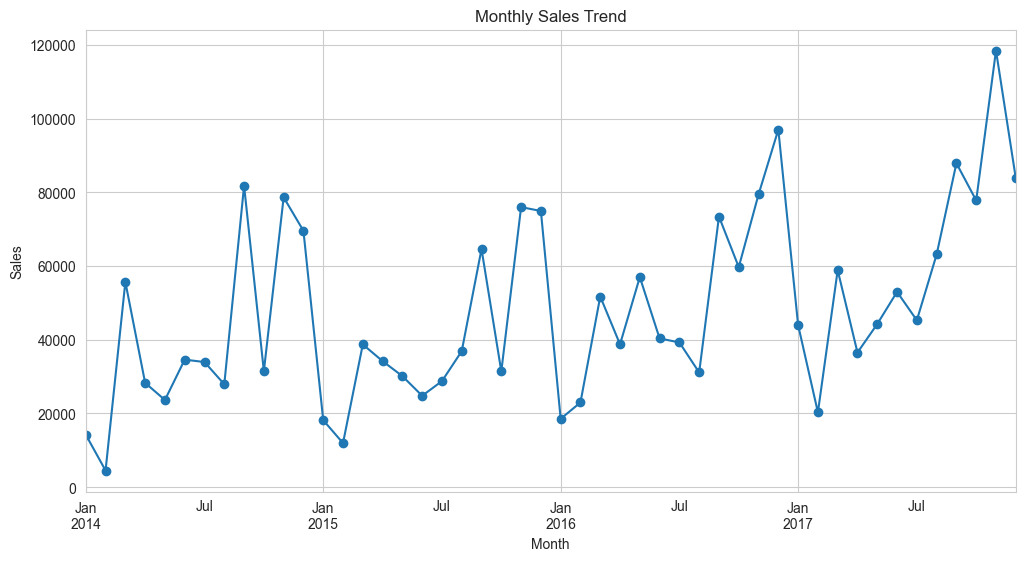

In [4]:
df["Month"] = df["Order Date"].dt.to_period("M")
monthly_sales = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(12,6))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.savefig("../images/monthly_sales_trend.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

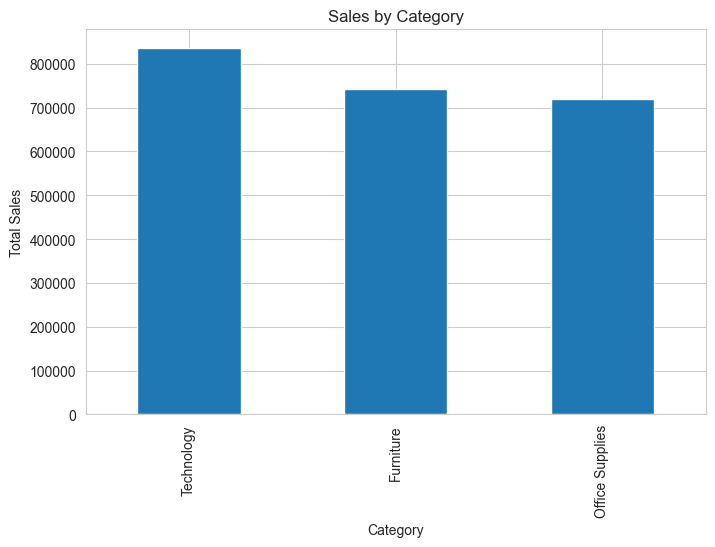

In [5]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.savefig("../images/sales_by_category.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

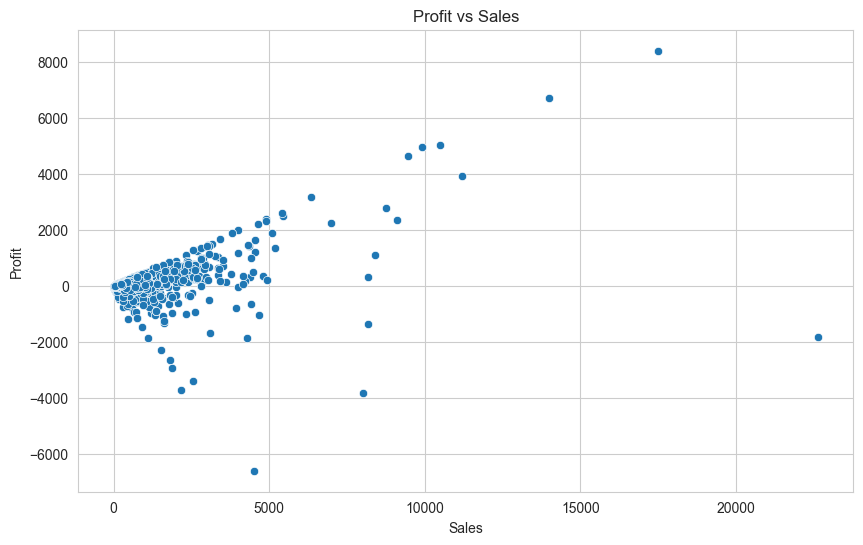

In [6]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit"
)

plt.title("Profit vs Sales")

plt.savefig("../images/profit_vs_sales.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

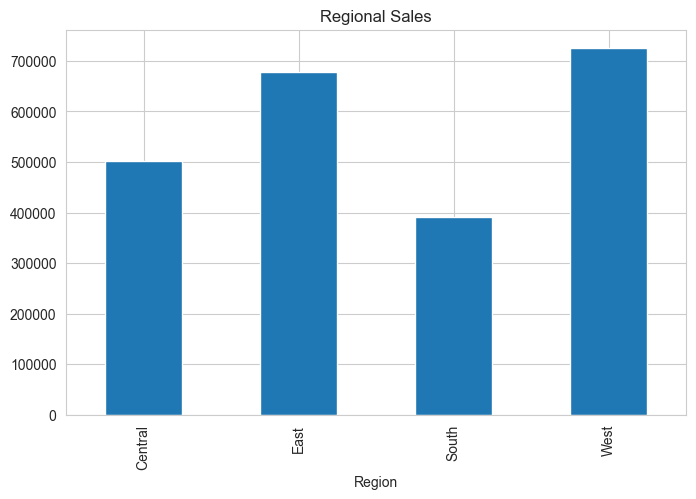

In [7]:
regional_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8,5))

regional_sales.plot(kind="bar")

plt.title("Regional Sales")

plt.savefig("../images/regional_sales.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

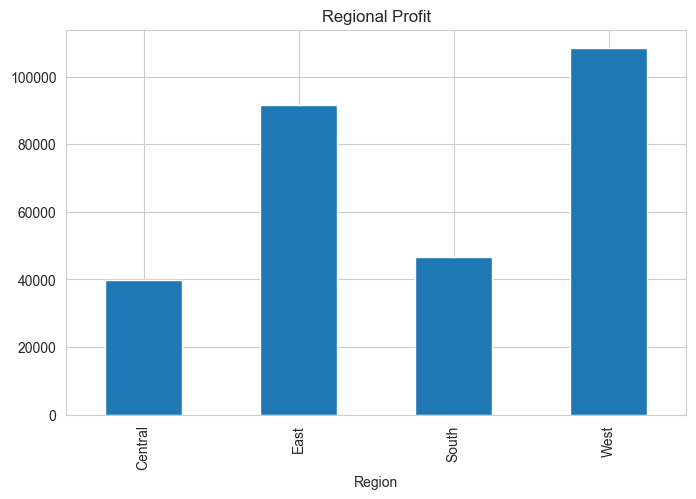

In [8]:
regional_profit = df.groupby("Region")["Profit"].sum()

plt.figure(figsize=(8,5))

regional_profit.plot(kind="bar")

plt.title("Regional Profit")

plt.savefig("../images/regional_profit.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

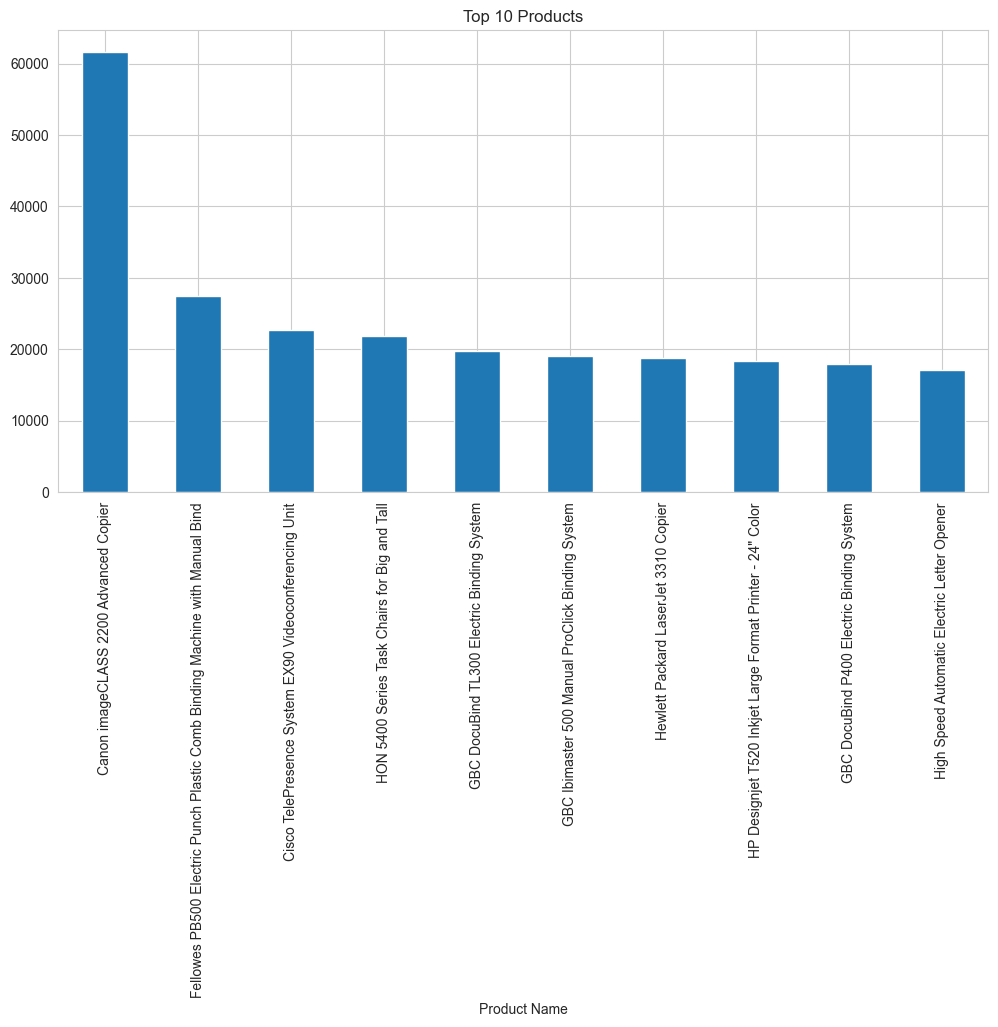

In [9]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_products.plot(kind="bar")

plt.title("Top 10 Products")

plt.xticks(rotation=90)

plt.savefig("../images/top10_products.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

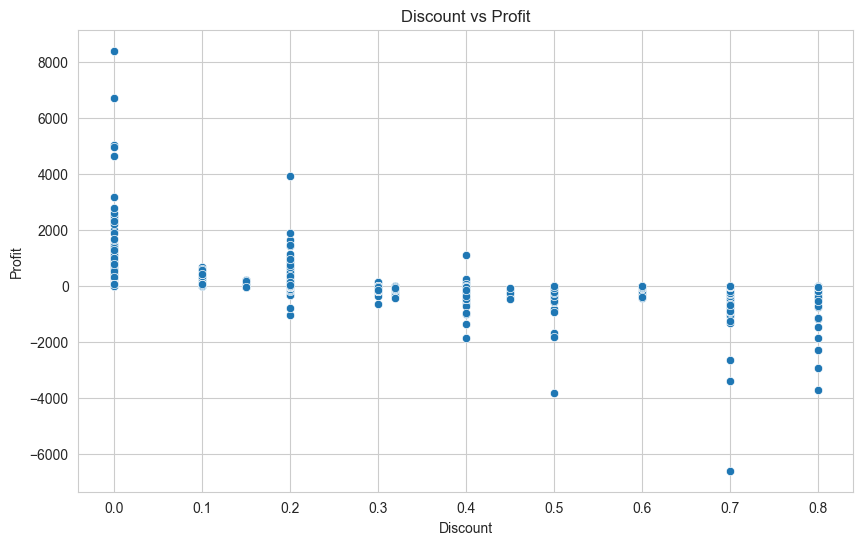

In [10]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit"
)

plt.title("Discount vs Profit")

plt.savefig("../images/discount_vs_profit.png",
            dpi=300,
            bbox_inches="tight")

plt.show()